## what would have happened in terms of weather if I was doing my trip in the 1950? let's find it out

##### precipitation_sum (mm)	temperature_2m_mean (°C)	wind_speed_10m_max (km/h)	wind_direction_10m_dominant (°)

In [1]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cmocean
from matplotlib import colormaps

df = pd.read_csv('/Users/filippomichelon/Documents/PersonalCode-local-utils/patagonia-trip-utils/openmeteo_data/track_viaggioneltempo/day_data.csv', sep=";")
ids = pd.read_csv('/Users/filippomichelon/Documents/PersonalCode-local-utils/patagonia-trip-utils/openmeteo_data/track_viaggioneltempo/day_id.csv', sep=";")

# Converte la colonna 'time' in datetime 
df["time"] = pd.to_datetime(df["time"])

# Crea una colonna temporanea con mese e giorno
df["mmdd"] = df["time"].dt.strftime("%m-%d")
df["year"] = df["time"].dt.year

# Converte la colonna 'time' in datetime 
ids["time"] = pd.to_datetime(ids["date"])

# Crea una colonna temporanea con mese e giorno
ids["mmdd"] = ids["time"].dt.strftime("%m-%d")
ids["year"] = ids["time"].dt.year

# select only days of interest for every location

In [2]:
filtered_list = []

for location in ids.location_id:
    filtered_df = df[(df["location_id"] == location) & (df["mmdd"] == ids.mmdd[location])]
    filtered_list.append(filtered_df)
    
# Unisci tutti i DataFrame filtrati
result_df = pd.concat(filtered_list, ignore_index=True)
result_df

,location_id,time,rain,temp,wind_speed,wind_dir,mmdd,year
0,0,1941-02-10,0.0,15.3,8.9,308,02-10,1941
1,0,1942-02-10,2.1,9.0,13.2,315,02-10,1942
2,0,1943-02-10,1.7,13.9,9.7,329,02-10,1943
3,0,1944-02-10,0.0,15.7,7.6,313,02-10,1944
4,0,1945-02-10,0.0,14.0,7.7,317,02-10,1945
...,...,...,...,...,...,...,...,...
1695,19,2021-03-04,0.0,17.5,7.7,116,03-04,2021
1696,19,2022-03-04,4.7,11.1,14.0,291,03-04,2022
1697,19,2023-03-04,0.0,14.5,10.1,314,03-04,2023
1698,19,2024-03-04,0.0,14.8,8.4,72,03-04,2024


# work now on plotting




### plot the dominant wind direction for every day during the trip

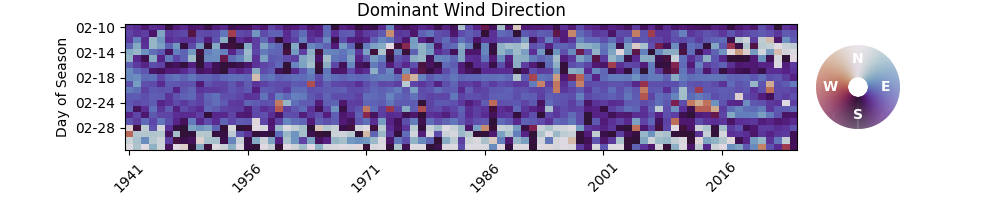

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.gridspec as gridspec

# === Data preparation ===
filt_list = []
for year in result_df.year.unique():
    filt_df = result_df[result_df["year"] == year].wind_dir
    filt_list.append(filt_df)

arrays = [filt_df.values for filt_df in filt_list]
matrix = np.vstack(arrays)
years = sorted(result_df["year"].unique())
sample_mmdd = result_df[result_df["year"] == years[0]]["mmdd"].values
matrix_df = pd.DataFrame(matrix, index=years, columns=sample_mmdd)

# Convert to wind *toward*
wind_toward = (matrix_df - 180) % 360

# === Plotting ===
cmap = colormaps['twilight']
angles = np.linspace(0, 2*np.pi, 360)
colors = cmap(np.linspace(0, 1, 360))

fig = plt.figure(figsize=(10, 2))
gs = gridspec.GridSpec(1, 2, width_ratios=[8, 1], wspace=0.05)

# --- Main wind direction heatmap ---
ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(wind_toward.T, cmap=cmap, aspect='auto')

ax0.set_title('Dominant Wind Direction')
ax0.set_ylabel("Day of Season")
ax0.set_xticks(range(0, len(matrix_df.index), 15))
ax0.set_xticklabels(matrix_df.index[::15], rotation=45)
ax0.set_yticks(range(0, len(matrix_df.columns), 4))
ax0.set_yticklabels([matrix_df.columns[i] for i in range(0, len(matrix_df.columns), 4)])

# --- Polar colormap legend ---
ax1 = fig.add_subplot(gs[1], projection='polar')
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)

for i in range(len(angles) - 1):
    ax1.plot(angles[i:i+2], [1, 1], color=colors[i], linewidth=36, solid_capstyle='butt')

for angle, label in zip(np.deg2rad([0, 90, 180, 270]), ['N', 'E', 'S', 'W']):
    ax1.text(angle, 0.8, label, fontsize=10, ha='center', va='center', color="white", fontweight='bold')

ax1.set(xticks=[], yticks=[], ylim=(0, 1.2))
ax1.spines['polar'].set_visible(False)

plt.subplots_adjust(bottom=0.25)  # Fix for clipped x-labels
plt.show()


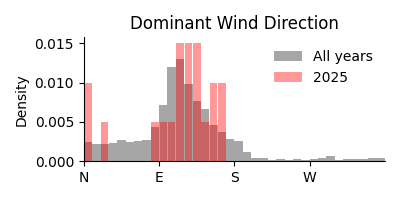

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

# Shift wind direction by -180° to get wind *toward*
wind_all = (result_df.wind_dir - 180) % 360
wind_2025 = (result_df[result_df["year"] == 2025].wind_dir - 180) % 360

# 36 equal bins (10° each)
bins = np.linspace(0, 360, 37)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Compute histograms
hist_all, _ = np.histogram(wind_all, bins=bins, density=True)
hist_2025, _ = np.histogram(wind_2025, bins=bins, density=True)

plt.figure(figsize=(4, 2))

# Base histogram: all years, color mapped
plt.bar(bin_centers, hist_all, width=10, color="grey", alpha=.7, label='All years')

# Overlay: 2025, uniform red, slightly thinner
plt.bar(bin_centers, hist_2025, width=9, color='red', alpha=0.4, label='2025')

# Compass direction ticks
plt.xticks([0, 90, 180, 270], ['N', 'E', 'S', 'W'])
plt.xlim(0, 360)
plt.ylabel('Density')
plt.title('Dominant Wind Direction')

# Remove plot box (top and right spines)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove legend frame
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


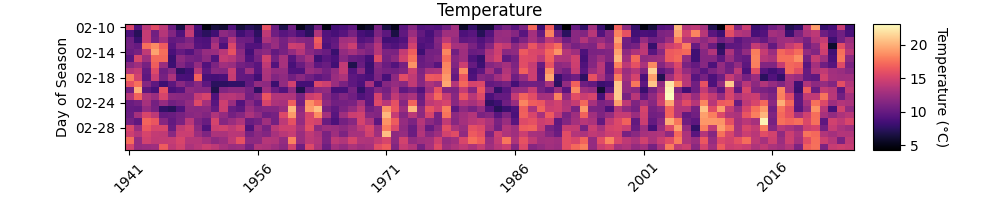

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.gridspec as gridspec

# === Data preparation ===
filt_list = []
for year in result_df.year.unique():
    filt_df = result_df[result_df["year"] == year].temp  # Use temp instead of wind_dir
    filt_list.append(filt_df)

arrays = [filt_df.values for filt_df in filt_list]
matrix = np.vstack(arrays)
years = sorted(result_df["year"].unique())
sample_mmdd = result_df[result_df["year"] == years[0]]["mmdd"].values
matrix_df = pd.DataFrame(matrix, index=years, columns=sample_mmdd)

# No wind transformations, matrix_df is temperature

# === Plotting ===
cmap = colormaps['magma']  # You can choose a more suitable colormap for temperature, e.g., 'coolwarm'

fig = plt.figure(figsize=(10, 2))
gs = gridspec.GridSpec(1, 2, width_ratios=[8, 0.3], wspace=0.05)

# --- Main temperature heatmap ---
ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(matrix_df.T, cmap=cmap, aspect='auto')

ax0.set_title('Temperature')
ax0.set_ylabel("Day of Season")
ax0.set_xticks(range(0, len(matrix_df.index), 15))
ax0.set_xticklabels(matrix_df.index[::15], rotation=45)
ax0.set_yticks(range(0, len(matrix_df.columns), 4))
ax0.set_yticklabels([matrix_df.columns[i] for i in range(0, len(matrix_df.columns), 4)])

# --- Add colorbar ---
ax_cbar = fig.add_subplot(gs[1])
cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label('Temperature (°C)', rotation=270, labelpad=15)

plt.subplots_adjust(bottom=0.25)  # Fix for clipped x-labels
plt.show()


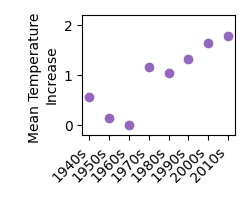

In [6]:
import matplotlib.pyplot as plt
import numpy as np

x = 10  # block size in years
data = matrix_df.mean(axis=1).values
years = matrix_df.index.values

# Number of blocks
n_blocks = len(data) // x

# Trim data and years so they divide evenly into blocks
data_trimmed = data[:n_blocks * x]
years_trimmed = years[:n_blocks * x]

# Reshape and compute block means
data_blocks = data_trimmed.reshape(n_blocks, x)
mean_blocks = data_blocks.mean(axis=1)

years_blocks = years_trimmed.reshape(n_blocks, x)

# Create labels as "startYear-endYear" for each block
xtick_labels = [f"{(block[0] // 10) * 10}s" for block in years_blocks]

plt.figure(figsize=(2.5, 2))
plt.scatter(np.arange(n_blocks), mean_blocks - mean_blocks.min(), color=sns.color_palette()[4])
plt.xticks(ticks=np.arange(n_blocks), labels=xtick_labels, rotation=45, ha='right')
plt.ylabel('Mean Temperature \nIncrease')
plt.ylim(-.2, 2.2)  # Limite asse y da 0 a 2
plt.tight_layout()
plt.show()


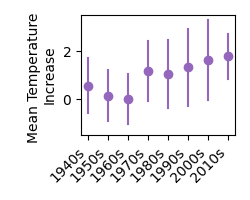

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Assumo che seaborn sia importato per i colori

x = 10  # block size in years
data = matrix_df.mean(axis=1).values
years = matrix_df.index.values

# Number of blocks
n_blocks = len(data) // x

# Trim data and years so they divide evenly into blocks
data_trimmed = data[:n_blocks * x]
years_trimmed = years[:n_blocks * x]

# Reshape and compute block means and std
data_blocks = data_trimmed.reshape(n_blocks, x)
mean_blocks = data_blocks.mean(axis=1)
std_blocks = data_blocks.std(axis=1)

years_blocks = years_trimmed.reshape(n_blocks, x)

# Create labels as "startYear-endYear" for each block
xtick_labels = [f"{(block[0] // 10) * 10}s" for block in years_blocks]

plt.figure(figsize=(2.5, 2))

# Normalizziamo la media come prima
mean_norm = mean_blocks - mean_blocks.min()

color_dot = sns.color_palette()[4]
plt.scatter(np.arange(n_blocks), mean_norm, color=color_dot)

# Aggiungi linee verticali (error bars) per std
for i in range(n_blocks):
    plt.plot([i, i], [mean_norm[i] - std_blocks[i], mean_norm[i] + std_blocks[i]], color=color_dot, linewidth=1.5)

plt.xticks(ticks=np.arange(n_blocks), labels=xtick_labels, rotation=45, ha='right')
plt.ylabel('Mean Temperature \nIncrease')
plt.ylim(-1.5, 3.5)
plt.tight_layout()
plt.show()
